# Stage-2 matched-only Lund DNN classifier

This notebook trains the **Stage-2 classifier** only on matched events:

| Stage-2 label | Original `channel2` | Meaning |
|---:|---:|---|
| 0 | 1 | $g\to q\bar q$-like / `qqbar` |
| 1 | 2 | $q\to qg$-like / `qg` |
| 2 | 3 | $g\to gg$-like / `gg-like` |

It **drops the unmatched category** (`channel2 == 0`) and also drops `channel2 == 4` (`rest`).
Everything else follows the same structure as your 4-class notebook: same input variables, same event-level split, same preprocessing, same DNN architecture, same class-weight strategy, and same evaluation style.

`dpsi12` is not used as an input feature. It is kept only for post-training physics plots.


In [1]:

import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from joblib import dump, load
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
    auc,
)
from sklearn.model_selection import GroupShuffleSplit, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.utils.class_weight import compute_class_weight

try:
    import tensorflow as tf
    from tensorflow import keras
    from tensorflow.keras import layers
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError(
        "TensorFlow is required for this notebook. Install it with: pip install tensorflow"
    ) from exc

warnings.filterwarnings("ignore", category=FutureWarning)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

print("TensorFlow:", tf.__version__)

TensorFlow: 2.16.2


## 1. Paths

Change `CSV_PATH` if your file is somewhere else. The fallback list includes the uploaded sandbox path and common local names.

In [2]:

CSV_PATH = Path("merged_ML.csv")

fallback_paths = [
    Path("merged_ML.csv"),
    Path("merged_ML(1).csv"),
    Path("../csv/merged_ML.csv"),
    Path("../merged_ML.csv"),
    Path("/mnt/data/merged_ML(1).csv"),
    Path("/mnt/data/merged_ML.csv"),
]

if not CSV_PATH.exists():
    for path in fallback_paths:
        if path.exists():
            CSV_PATH = path
            break

if not CSV_PATH.exists():
    raise FileNotFoundError(
        "Could not find merged_ML.csv. Set CSV_PATH to the location of your CSV."
    )

MODEL_DIR = Path("models_stage2_matched_3class")
OUTPUT_DIR = Path("outputs_stage2_matched_3class")
MODEL_DIR.mkdir(exist_ok=True)
OUTPUT_DIR.mkdir(exist_ok=True)

print("Using CSV:", CSV_PATH.resolve())
print("Stage-2 model directory:", MODEL_DIR.resolve())
print("Stage-2 output directory:", OUTPUT_DIR.resolve())

Using CSV: /Users/alexmendonca/Desktop/pic2/csv/merged_ML.csv
Stage-2 model directory: /Users/alexmendonca/Desktop/pic2/python/models_stage2_matched_3class
Stage-2 output directory: /Users/alexmendonca/Desktop/pic2/python/outputs_stage2_matched_3class


## 2. Load CSV and build features

The DNN inputs are the same as in the Stage-2 3-class notebook.  
The original target is `channel2`, but for Stage 2 we keep only original classes `1, 2, 3` and remap them to labels `0, 1, 2`.

`dpsi12` is explicitly excluded from the DNN inputs.


In [3]:

def add_engineered_features(df: pd.DataFrame) -> pd.DataFrame:
    """Add stable transformed and combination features.

    Important: this function does not touch dpsi12 except keeping it available
    for post-training plots.
    """
    df = df.copy()

    # Stabilize long-tailed positive variables.
    for col in ["pt_dispersion3", "pt_dispersion4"]:
        if col in df.columns:
            df[col] = np.log1p(df[col].clip(lower=0))

    if "kt2" in df.columns:
        df["kt2"] = np.log1p(df["kt2"].clip(lower=0))

    if "deltaR34" in df.columns:
        dr = df["deltaR34"].clip(lower=1e-4)
        df["deltaR34"] = np.log1p(1.0 / dr)

    # z variables
    df["z_sum"] = df["z1"] + df["z2"]
    df["z_absdiff"] = np.abs(df["z1"] - df["z2"])
    df["z_min"] = np.minimum(df["z1"], df["z2"])
    df["z_max"] = np.maximum(df["z1"], df["z2"])
    df["z_minmax_ratio"] = df["z_min"] / (df["z_max"] + 1e-8)

    # Pairwise subjet observables. Use sum/absdiff/min/max/ratio to avoid relying
    # too much on arbitrary subjet-3/subjet-4 ordering.
    paired_bases = [
        ("N_charged3", "N_charged4", "N_charged"),
        ("N_all3", "N_all4", "N_all"),
        ("pt_weight3", "pt_weight4", "pt_weight"),
        ("pt_dispersion3", "pt_dispersion4", "pt_dispersion"),
    ]

    for c3, c4, name in paired_bases:
        if c3 not in df.columns or c4 not in df.columns:
            continue
        v3 = df[c3]
        v4 = df[c4]
        vmin = np.minimum(v3, v4)
        vmax = np.maximum(v3, v4)
        df[f"{name}_sum"] = v3 + v4
        df[f"{name}_absdiff"] = np.abs(v3 - v4)
        df[f"{name}_min"] = vmin
        df[f"{name}_max"] = vmax
        df[f"{name}_minmax_ratio"] = vmin / (vmax + 1e-8)

    return df


df_raw = pd.read_csv(CSV_PATH)
print("Raw shape:", df_raw.shape)
print("Columns:", df_raw.columns.tolist())

#df = add_engineered_features(df_raw)
df = df_raw.copy()

ORIGINAL_TARGET = "channel2"
if ORIGINAL_TARGET not in df.columns:
    raise ValueError(f"Missing target column {ORIGINAL_TARGET!r}")

df = df.dropna(subset=[ORIGINAL_TARGET]).copy()
df[ORIGINAL_TARGET] = df[ORIGINAL_TARGET].astype(int)

print("Original channel2 counts:")
display(df[ORIGINAL_TARGET].value_counts().sort_index().rename("count").to_frame())

Raw shape: (5847342, 17)
Columns: ['Event', 'Jet', 'z1', 'z2', 'deltaR34', 'kt2', 'N_charged3', 'N_charged4', 'N_all3', 'N_all4', 'pt_weight3', 'pt_weight4', 'pt_dispersion3', 'pt_dispersion4', 'tau_time', 'channel2', 'dpsi12']
Original channel2 counts:


,count
channel2,
0,4397983
1,179810
2,358498
3,857140
4,53911


## 3. Select matched classes and define training inputs

Stage-2 behavior:

- Drop `channel2 = 0` (`unmatched`)
- Keep `channel2 = 1, 2, 3`
- Remap labels: `1 -> 0`, `2 -> 1`, `3 -> 2`
- Drop identifiers and non-input variables: `Event`, `Jet`, `tau_time`, `dpsi12`, `channel2`, `stage2_target`


In [4]:

# Stage 2: keep only matched classes: qqbar, qg, gg.
# Original labels:
#   channel2 = 1 -> qqbar
#   channel2 = 2 -> qg
#   channel2 = 3 -> gg-like
KEEP_ORIGINAL_CLASSES = [1, 2, 3]
df = df[df[ORIGINAL_TARGET].isin(KEEP_ORIGINAL_CLASSES)].copy()

STAGE2_TARGET = "stage2_target"
ORIGINAL_TO_STAGE2 = {
    1: 0,  # qqbar
    2: 1,  # qg
    3: 2,  # gg-like
}
STAGE2_TO_ORIGINAL = {v: k for k, v in ORIGINAL_TO_STAGE2.items()}

CLASS_NAMES = {
    0: "qqbar",
    1: "qg",
    2: "gg-like",
}
ORIGINAL_CLASS_NAMES = {
    1: "qqbar",
    2: "qg",
    3: "gg-like",
}
expected_classes = np.array([0, 1, 2], dtype=np.int64)

df[STAGE2_TARGET] = df[ORIGINAL_TARGET].map(ORIGINAL_TO_STAGE2).astype(np.int64)

print("Counts after dropping unmatched and keeping original channel2 = 1,2,3:")
display(df[ORIGINAL_TARGET].value_counts().sort_index().rename("count").to_frame())
print("Fractions in original labels:")
display((100 * df[ORIGINAL_TARGET].value_counts(normalize=True).sort_index()).rename("percent").to_frame())

print("\nStage-2 target counts after remapping:")
display(df[STAGE2_TARGET].value_counts().sort_index().rename("count").to_frame())

# Never use dpsi12 as an input feature.
ADDITIONAL_COLUMNS_TO_DROP = ["Event", "Jet", "dpsi12", "tau_time"]
columns_to_drop = sorted(
    set([ORIGINAL_TARGET, STAGE2_TARGET] + ADDITIONAL_COLUMNS_TO_DROP),
    key=lambda col: list(df.columns).index(col) if col in df.columns else 10**9,
)

feature_columns = [col for col in df.columns if col not in columns_to_drop]

# Keep only numeric features.
X = df[feature_columns].copy()
non_numeric_columns = X.select_dtypes(exclude=[np.number]).columns.tolist()
if non_numeric_columns:
    raise ValueError(f"Non-numeric feature columns found: {non_numeric_columns}")

# Replace inf with nan so the imputer can handle them.
X = X.replace([np.inf, -np.inf], np.nan)
y = df[STAGE2_TARGET].to_numpy(dtype=np.int64)
y_original = df[ORIGINAL_TARGET].to_numpy(dtype=np.int64)

print("Dropped columns:", columns_to_drop)
print("Number of features:", len(feature_columns))
print("Feature columns:")
for c in feature_columns:
    print("  -", c)

assert "dpsi12" not in feature_columns
assert ORIGINAL_TARGET not in feature_columns
assert STAGE2_TARGET not in feature_columns


Counts after dropping unmatched and keeping original channel2 = 1,2,3:


,count
channel2,
1,179810
2,358498
3,857140


Fractions in original labels:


,percent
channel2,
1,12.885468
2,25.690531
3,61.424001



Stage-2 target counts after remapping:


,count
stage2_target,
0,179810
1,358498
2,857140


Dropped columns: ['Event', 'Jet', 'tau_time', 'channel2', 'dpsi12', 'stage2_target']
Number of features: 12
Feature columns:
  - z1
  - z2
  - deltaR34
  - kt2
  - N_charged3
  - N_charged4
  - N_all3
  - N_all4
  - pt_weight3
  - pt_weight4
  - pt_dispersion3
  - pt_dispersion4


## 4. Event-level train/validation/test split and preprocessing

Splitting by event is safer than row-wise random splitting because it avoids putting jets from the same event in both train and test.

This split is performed **after dropping unmatched events**, so Stage 2 is trained and evaluated only on matched events.


In [5]:

USE_EVENT_GROUP_SPLIT = "Event" in df.columns

if USE_EVENT_GROUP_SPLIT:
    groups = df["Event"].to_numpy()

    splitter_test = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=RANDOM_STATE)
    trainval_idx, test_idx = next(splitter_test.split(X, y, groups=groups))

    X_trainval = X.iloc[trainval_idx]
    X_test = X.iloc[test_idx]
    y_trainval = y[trainval_idx]
    y_test = y[test_idx]
    groups_trainval = groups[trainval_idx]

    splitter_val = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=RANDOM_STATE + 1)
    train_rel_idx, val_rel_idx = next(splitter_val.split(X_trainval, y_trainval, groups=groups_trainval))

    X_train = X_trainval.iloc[train_rel_idx]
    X_val = X_trainval.iloc[val_rel_idx]
    y_train = y_trainval[train_rel_idx]
    y_val = y_trainval[val_rel_idx]
else:
    print("No Event column found. Falling back to stratified row-wise split.")
    X_trainval, X_test, y_trainval, y_test = train_test_split(
        X, y, test_size=0.15, random_state=RANDOM_STATE, stratify=y,
    )
    X_train, X_val, y_train, y_val = train_test_split(
        X_trainval, y_trainval, test_size=0.15, random_state=RANDOM_STATE, stratify=y_trainval,
    )

print("Train:", X_train.shape, "Validation:", X_val.shape, "Test:", X_test.shape)

print("\nClass fractions:")
for name, yy in [("Train", y_train), ("Validation", y_val), ("Test", y_test)]:
    vc = pd.Series(yy).value_counts(normalize=True).sort_index()
    print(name)
    for c in expected_classes:
        print(f"  {c} {CLASS_NAMES[int(c)]:>10s}: {vc.get(c, 0.0):.4%}")

preprocessor = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

X_train_pp = preprocessor.fit_transform(X_train).astype("float32")
X_val_pp = preprocessor.transform(X_val).astype("float32")
X_test_pp = preprocessor.transform(X_test).astype("float32")

dump(preprocessor, MODEL_DIR / "stage2_matched_3class_preprocessor.joblib")
with open(MODEL_DIR / "stage2_matched_3class_feature_columns.json", "w") as f:
    json.dump(feature_columns, f, indent=2)

print("Saved preprocessor and feature list.")

Train: (1008347, 12) Validation: (177895, 12) Test: (209206, 12)

Class fractions:
Train
  0      qqbar: 12.8696%
  1         qg: 25.6959%
  2    gg-like: 61.4345%
Validation
  0      qqbar: 12.9054%
  1         qg: 25.6578%
  2    gg-like: 61.4368%
Test
  0      qqbar: 12.9451%
  1         qg: 25.6924%
  2    gg-like: 61.3625%
Saved preprocessor and feature list.


## 5. Class weights

The Stage-2 sample is still imbalanced: usually `qqbar` is much rarer than `qg` and `gg-like`. Class weights help the network not ignore the smaller matched classes.


In [6]:

alpha_power = 0.75  # 1.0 = full balanced weights, 0.5 = softer, 0.0 = no weighting

raw_class_weights = compute_class_weight(
    class_weight="balanced",
    classes=expected_classes,
    y=y_train,
)
class_weight_map = {
    int(c): float(w ** alpha_power)
    for c, w in zip(expected_classes, raw_class_weights)
}

print("Raw balanced weights:")
print({int(c): float(w) for c, w in zip(expected_classes, raw_class_weights)})
print("\nWeights used:")
print(class_weight_map)

Raw balanced weights:
{0: 2.590087590865891, 1: 1.297222994113046, 2: 0.5425832387637018}

Weights used:
{0: 2.041671368104428, 1: 1.2155168362077684, 2: 0.6321931418236866}


## 6. Build and train the Stage-2 3-class DNN

This uses the same architecture as the Stage-2 3-class notebook, but the final softmax has 3 outputs instead of 4.


In [7]:

def build_stage2_dnn(input_dim: int, n_classes: int = 3) -> keras.Model:
    model = keras.Sequential(
        [
            layers.Input(shape=(input_dim,), name="features"),

            layers.Dense(256, activation="relu", kernel_regularizer=keras.regularizers.l2(1e-5), name="dense_1"),
            layers.BatchNormalization(name="bn_1"),
            layers.Dropout(0.20, name="dropout_1"),

            layers.Dense(128, activation="relu", kernel_regularizer=keras.regularizers.l2(1e-5), name="dense_2"),
            layers.BatchNormalization(name="bn_2"),
            layers.Dropout(0.20, name="dropout_2"),

            layers.Dense(64, activation="relu", kernel_regularizer=keras.regularizers.l2(1e-5), name="dense_3"),
            layers.BatchNormalization(name="bn_3"),
            layers.Dropout(0.10, name="dropout_3"),

            layers.Dense(n_classes, activation="softmax", name="class_probabilities"),
        ],
        name="lund_stage2_matched_3class_dnn",
    )

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

model = build_stage2_dnn(input_dim=X_train_pp.shape[1], n_classes=len(expected_classes))
model.summary()

Model: "lund_stage2_matched_3class_dnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 256)            │         3,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 256)            │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_2 (BatchNormalization)       │ (None, 128)            │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_3 (BatchNormalization)       │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ class_probabilities (Dense)     │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 46,467 (181.51 KB)

 Trainable params: 45,571 (178.01 KB)

 Non-trainable params: 896 (3.50 KB)

In [8]:
class ValMetricsCallback(tf.keras.callbacks.Callback):
    def __init__(self, X_val, y_val, batch_size=8192):
        super().__init__()
        self.X_val = X_val
        self.y_val = y_val
        self.batch_size = batch_size

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}

        y_score = self.model.predict(
            self.X_val,
            batch_size=self.batch_size,
            verbose=0
        )
        y_pred = np.argmax(y_score, axis=1)

        logs["val_macro_f1"] = f1_score(
            self.y_val,
            y_pred,
            average="macro",
            zero_division=0
        )

        logs["val_balanced_accuracy"] = balanced_accuracy_score(
            self.y_val,
            y_pred
        )

        print(
            f" — val_macro_f1: {logs['val_macro_f1']:.4f}"
            f" — val_balanced_accuracy: {logs['val_balanced_accuracy']:.4f}"
        )

In [9]:
EPOCHS = 100
BATCH_SIZE = 1024
MONITOR_METRIC = "val_macro_f1"

val_metrics = ValMetricsCallback(X_val_pp, y_val)

checkpoint = tf.keras.callbacks.ModelCheckpoint(
    filepath=str(MODEL_DIR / "stage2_matched_3class_dnn_best.keras"),
    monitor=MONITOR_METRIC,
    mode="max",
    save_best_only=True,
    save_weights_only=False,
    verbose=1,
)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor=MONITOR_METRIC,
    mode="max",
    patience=15,
    restore_best_weights=True,
    verbose=1,
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor=MONITOR_METRIC,
    mode="max",
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    verbose=1,
)

callbacks = [
    val_metrics,
    checkpoint,
    early_stop,
    reduce_lr,
]

history = model.fit(
    X_train_pp,
    y_train,
    validation_data=(X_val_pp, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weight_map,
    callbacks=callbacks,
    verbose=1,
)

model.save(MODEL_DIR / "stage2_matched_3class_dnn_final.keras")

print("Best validation loss:", min(history.history["val_loss"]))
print("Best validation macro F1:", max(history.history["val_macro_f1"]))
print("Best validation balanced accuracy:", max(history.history["val_balanced_accuracy"]))

Epoch 1/100
984/985 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.5286 - loss: 1.0302 — val_macro_f1: 0.4613 — val_balanced_accuracy: 0.4677

Epoch 1: val_macro_f1 improved from None to 0.46132, saving model to models_stage2_matched_3class/stage2_matched_3class_dnn_best.keras

Epoch 1: finished saving model to models_stage2_matched_3class/stage2_matched_3class_dnn_best.keras
985/985 ━━━━━━━━━━━━━━━━━━━━ 30s 28ms/step - accuracy: 0.5589 - loss: 0.9960 - val_accuracy: 0.5859 - val_loss: 0.9419 - val_macro_f1: 0.4613 - val_balanced_accuracy: 0.4677 - learning_rate: 0.0010
Epoch 2/100
985/985 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.5853 - loss: 0.9712 — val_macro_f1: 0.4635 — val_balanced_accuracy: 0.4674

Epoch 2: val_macro_f1 improved from 0.46132 to 0.46353, saving model to models_stage2_matched_3class/stage2_matched_3class_dnn_best.keras

Epoch 2: finished saving model to models_stage2_matched_3class/stage2_matched_3class_dnn_best.keras
985/985 ━━━━━━━━━━━━━━━━━━━━ 20s 20ms/s

## 7. Training curves

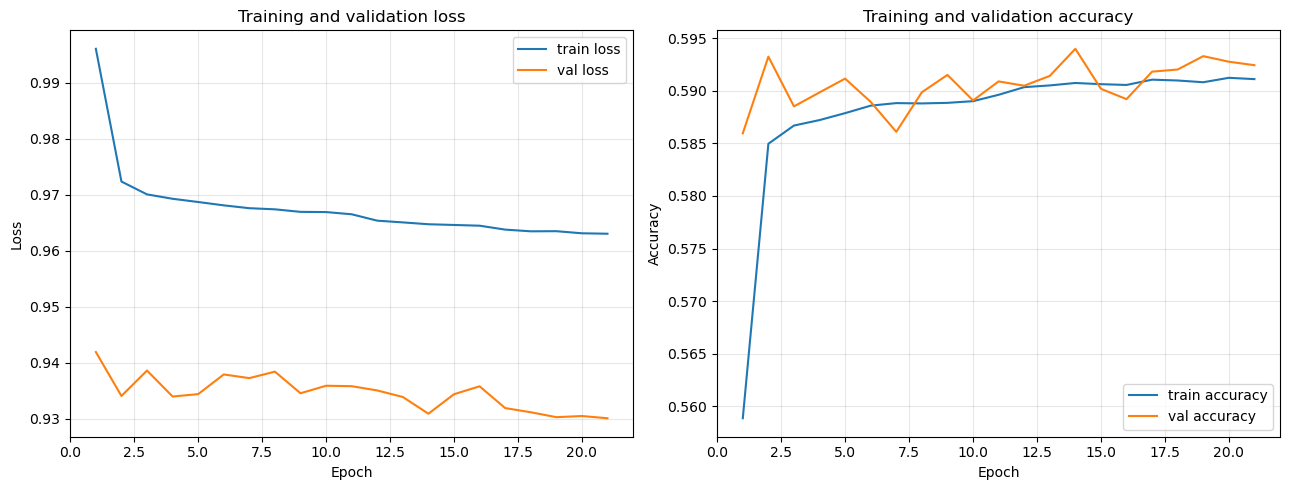

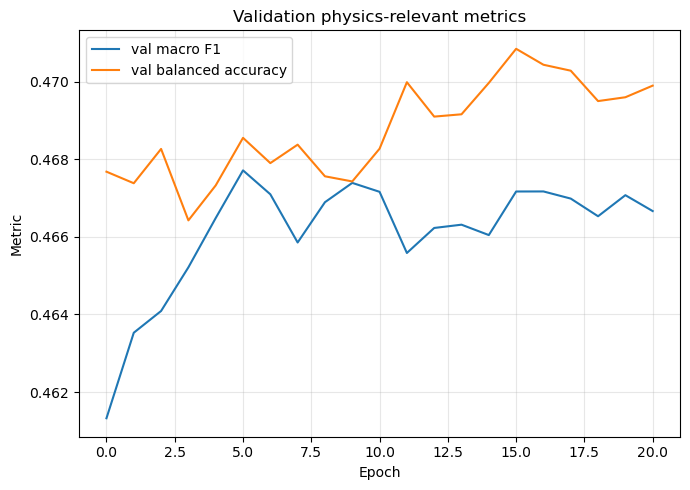

In [10]:

def plot_training_curves(history):
    hist = history.history
    epochs = np.arange(1, len(hist["loss"]) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    axes[0].plot(epochs, hist["loss"], label="train loss")
    axes[0].plot(epochs, hist["val_loss"], label="val loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].set_title("Training and validation loss")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(epochs, hist["accuracy"], label="train accuracy")
    axes[1].plot(epochs, hist["val_accuracy"], label="val accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].set_title("Training and validation accuracy")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "training_curves.png", dpi=160)
    plt.show()

plot_training_curves(history)

plt.figure(figsize=(7, 5))
plt.plot(history.history["val_macro_f1"], label="val macro F1")
plt.plot(history.history["val_balanced_accuracy"], label="val balanced accuracy")
plt.xlabel("Epoch")
plt.ylabel("Metric")
plt.title("Validation physics-relevant metrics")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Test-set evaluation

This evaluates the Stage-2 3-class classifier with:

- classification report
- confusion matrix
- one-vs-rest ROC-AUC and PR-AUC for each matched class
- score distributions by true matched class


Loaded best checkpoint: models_stage2_matched_3class/stage2_matched_3class_dnn_best.keras
Validation accuracy: 0.5889316731779982
Validation balanced accuracy: 0.4685515689259829
Validation macro F1: 0.46771308700679537
Test accuracy: 0.5891465827939926
Test balanced accuracy: 0.4688854724393476
Test macro F1: 0.4679756217498276

Test classification report:
              precision    recall  f1-score   support

       qqbar     0.3231    0.3447    0.3336     27082
          qg     0.3838    0.3003    0.3369     53750
     gg-like     0.7072    0.7617    0.7334    128374

    accuracy                         0.5891    209206
   macro avg     0.4714    0.4689    0.4680    209206
weighted avg     0.5744    0.5891    0.5798    209206



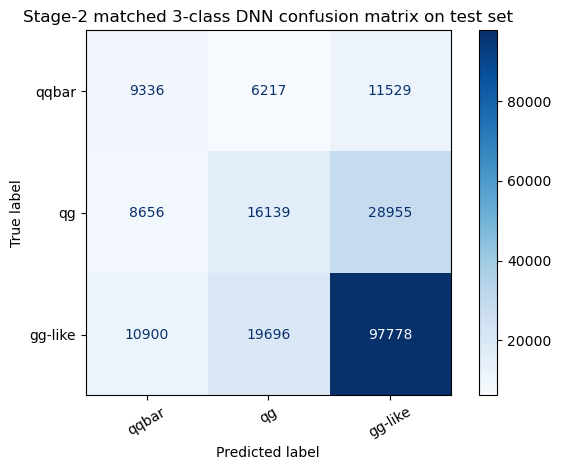

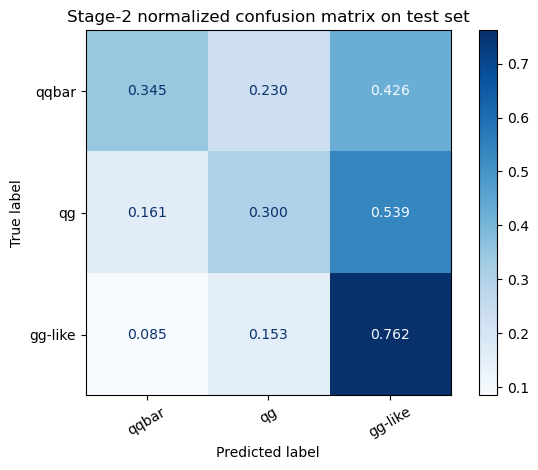

In [11]:

def predict_scores(model, X_pp):
    return model.predict(X_pp, batch_size=8192, verbose=0)

# Evaluate the checkpointed best model, not accidentally the final epoch model.
best_model_path = MODEL_DIR / "stage2_matched_3class_dnn_best.keras"
if best_model_path.exists():
    eval_model = tf.keras.models.load_model(best_model_path)
    print("Loaded best checkpoint:", best_model_path)
else:
    eval_model = model
    print("Best checkpoint not found; using current in-memory model.")

score_val = predict_scores(eval_model, X_val_pp)
score_test = predict_scores(eval_model, X_test_pp)

pred_val = score_val.argmax(axis=1)
pred_test = score_test.argmax(axis=1)

print("Validation accuracy:", accuracy_score(y_val, pred_val))
print("Validation balanced accuracy:", balanced_accuracy_score(y_val, pred_val))
print("Validation macro F1:", f1_score(y_val, pred_val, average="macro", zero_division=0))
print("Test accuracy:", accuracy_score(y_test, pred_test))
print("Test balanced accuracy:", balanced_accuracy_score(y_test, pred_test))
print("Test macro F1:", f1_score(y_test, pred_test, average="macro", zero_division=0))

print("\nTest classification report:")
print(classification_report(
    y_test,
    pred_test,
    labels=expected_classes,
    target_names=[CLASS_NAMES[int(c)] for c in expected_classes],
    digits=4,
    zero_division=0,
))

cm = confusion_matrix(y_test, pred_test, labels=expected_classes)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[CLASS_NAMES[int(c)] for c in expected_classes],
)
disp.plot(values_format="d", cmap="Blues", xticks_rotation=30)
plt.title("Stage-2 matched 3-class DNN confusion matrix on test set")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "stage2_confusion_matrix_test.png", dpi=160)
plt.show()

cm_norm = confusion_matrix(y_test, pred_test, labels=expected_classes, normalize="true")
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_norm,
    display_labels=[CLASS_NAMES[int(c)] for c in expected_classes],
)
disp.plot(values_format=".3f", cmap="Blues", xticks_rotation=30)
plt.title("Stage-2 normalized confusion matrix on test set")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "stage2_confusion_matrix_test_normalized.png", dpi=160)
plt.show()


In [12]:

# One-vs-rest ROC-AUC and PR-AUC per class
rows = []
for c in expected_classes:
    y_true_c = (y_test == c).astype(int)
    y_score_c = score_test[:, int(c)]

    roc = roc_auc_score(y_true_c, y_score_c)
    pr = average_precision_score(y_true_c, y_score_c)
    baseline = y_true_c.mean()

    rows.append({
        "class": int(c),
        "name": CLASS_NAMES[int(c)],
        "fraction": baseline,
        "roc_auc": roc,
        "pr_auc": pr,
    })

metric_df = pd.DataFrame(rows)
display(metric_df)
metric_df.to_csv(OUTPUT_DIR / "one_vs_rest_metrics.csv", index=False)

,class,name,fraction,roc_auc,pr_auc
0,0,qqbar,0.129451,0.712850,0.313890
1,1,qg,0.256924,0.619305,0.367137
2,2,gg-like,0.613625,0.678491,0.738895


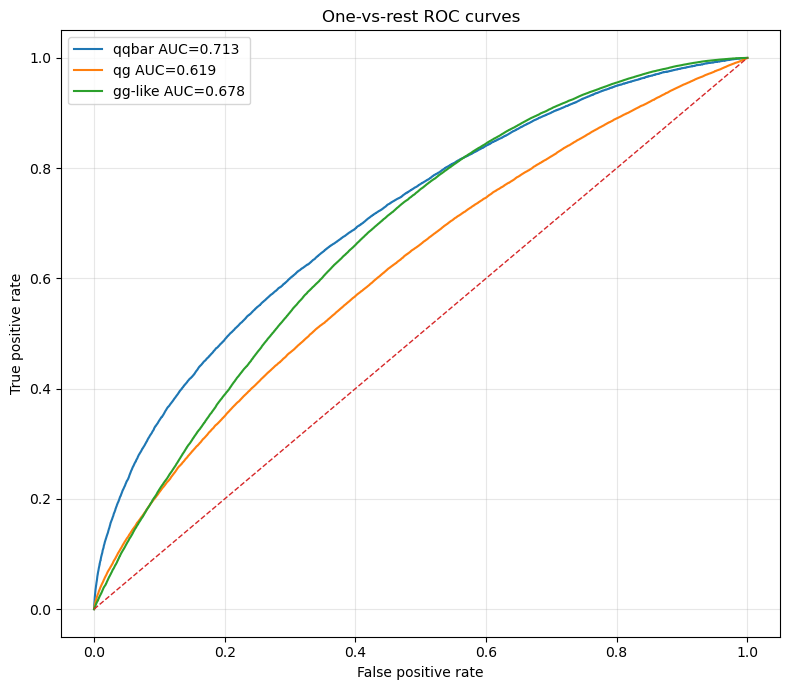

In [13]:

# ROC curves
plt.figure(figsize=(8, 7))
for c in expected_classes:
    y_true_c = (y_test == c).astype(int)
    y_score_c = score_test[:, int(c)]
    fpr, tpr, _ = roc_curve(y_true_c, y_score_c)
    roc = roc_auc_score(y_true_c, y_score_c)
    plt.plot(fpr, tpr, label=f"{CLASS_NAMES[int(c)]} AUC={roc:.3f}")

plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1)
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("One-vs-rest ROC curves")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "roc_curves_one_vs_rest.png", dpi=160)
plt.show()

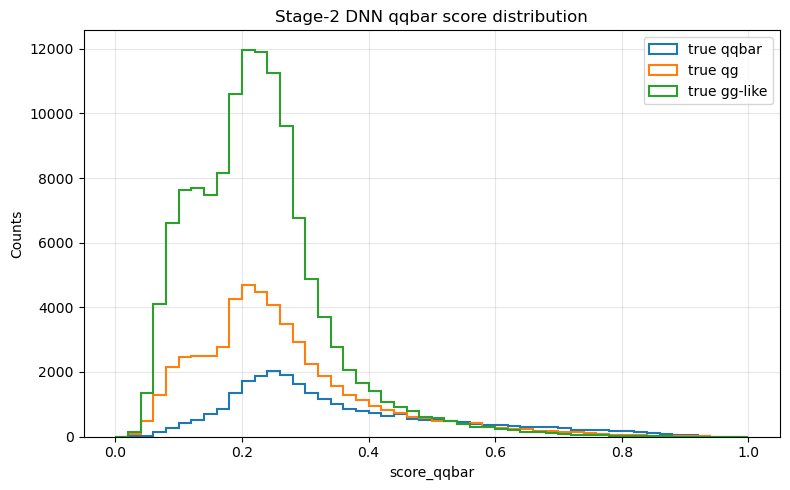

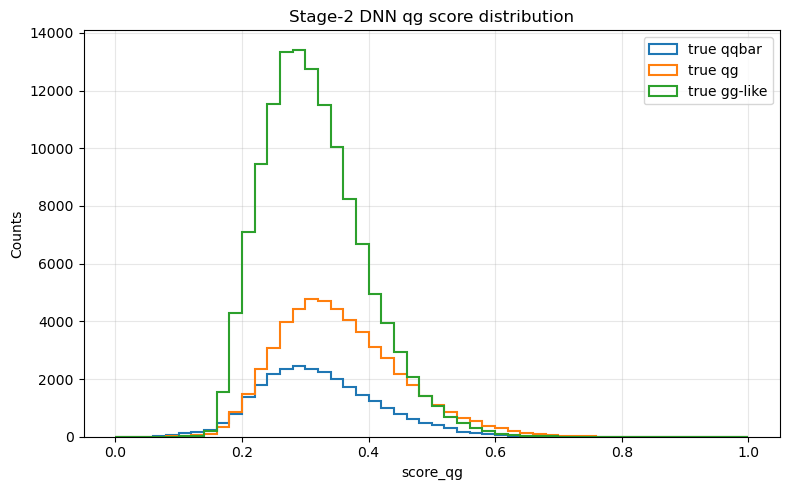

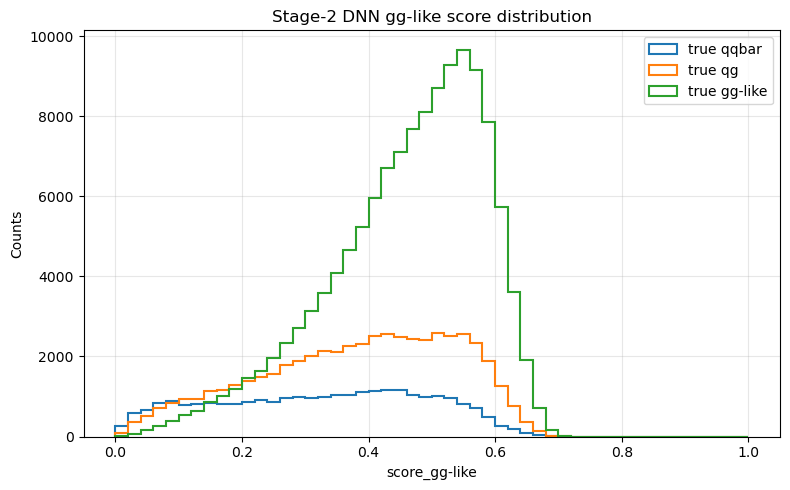

In [14]:

# Score distributions by true class
for c in expected_classes:
    plt.figure(figsize=(8, 5))
    bins = np.linspace(0, 1, 51)
    for true_c in expected_classes:
        mask = y_test == true_c
        plt.hist(
            score_test[mask, int(c)],
            bins=bins,
            histtype="step",
            density=False,
            linewidth=1.5,
            label=f"true {CLASS_NAMES[int(true_c)]}",
            range=[0.0, 1.0]
        )
        max_score = score_test[mask, int(c)].max()
    plt.xlabel(f"score_{CLASS_NAMES[int(c)]}")
    plt.ylabel("Counts")
    plt.title(f"Stage-2 DNN {CLASS_NAMES[int(c)]} score distribution")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"stage2_score_distribution_class_{int(c)}.png", dpi=160)
    plt.show()

## Plot `dpsi12` of Stage-2 test subjects

This plots `dpsi12` for matched-only Stage-2 score selections:

- `score_qqbar >= 0.6`
- `score_qg >= 0.6`
- `score_gg >= 0.6`

Stack components are the true Stage-2 labels.



score_qqbar >= 0.6
Selected fraction: 0.029071823943863942
    qqbar: purity=0.527, efficiency=0.118, N=3203
       qg: purity=0.288, efficiency=0.033, N=1752
  gg-like: purity=0.185, efficiency=0.009, N=1127


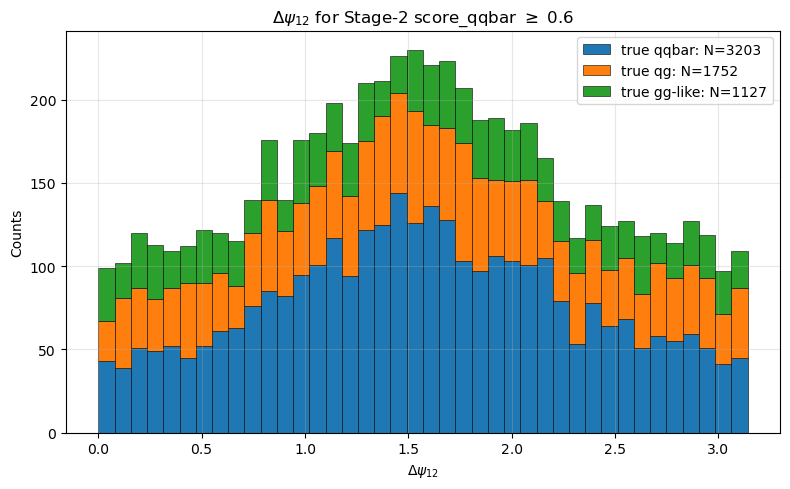


score_qg >= 0.6
Selected fraction: 0.005664273491200062
    qqbar: purity=0.105, efficiency=0.005, N=125
       qg: purity=0.675, efficiency=0.015, N=800
  gg-like: purity=0.219, efficiency=0.002, N=260


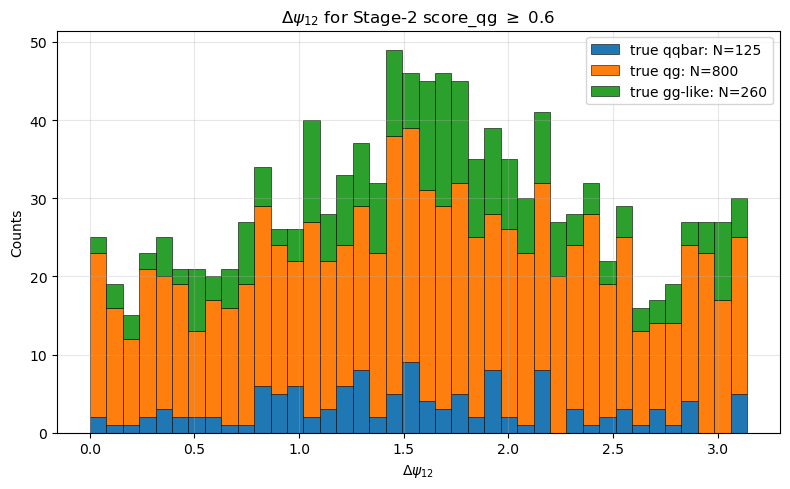


score_gg >= 0.6
Selected fraction: 0.07295201858455302
    qqbar: purity=0.038, efficiency=0.021, N=579
       qg: purity=0.167, efficiency=0.047, N=2543
  gg-like: purity=0.795, efficiency=0.095, N=12140


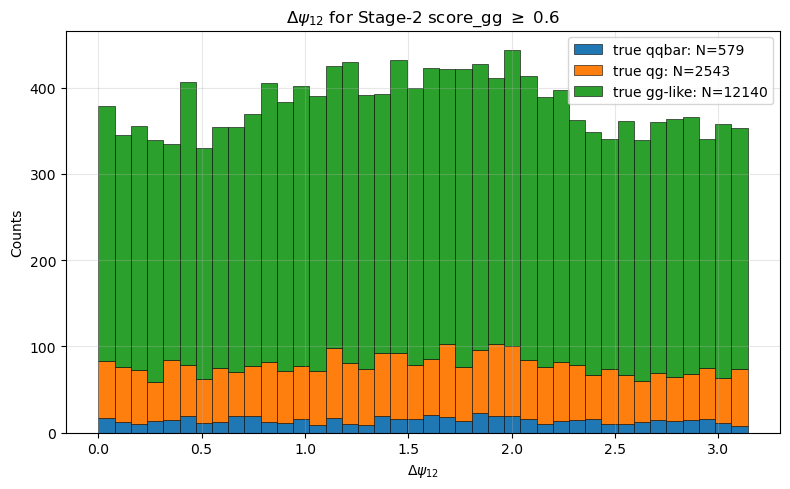

In [15]:
# Plot dpsi12 of test subjects with score >= 0.6
# One stacked histogram per score cut.
# Stack components are the true Stage-2 labels.

SCORE_THRESHOLD = 0.6
BINS = 40

score_class_names = {
    0: "qqbar",
    1: "qg",
    2: "gg",
}

test_df = df.loc[X_test.index].copy()
dpsi_test = test_df["dpsi12"].to_numpy(dtype=float)

finite_dpsi = dpsi_test[np.isfinite(dpsi_test)]
if np.nanmax(np.abs(finite_dpsi)) > 2 * np.pi + 0.5:
    print("dpsi12 looks like degrees; converting to radians.")
    dpsi_test = np.deg2rad(dpsi_test)

finite_dpsi = dpsi_test[np.isfinite(dpsi_test)]
if finite_dpsi.min() >= -0.05 and finite_dpsi.max() <= np.pi + 0.05:
    dpsi_range = (0, np.pi)
else:
    dpsi_range = (finite_dpsi.min(), finite_dpsi.max())

for score_class in expected_classes:
    score_class = int(score_class)

    score_mask = score_test[:, score_class] >= SCORE_THRESHOLD

    hist_data = []
    hist_labels = []

    for true_class in expected_classes:
        true_class = int(true_class)

        mask = (
            score_mask
            & (y_test == true_class)
            & np.isfinite(dpsi_test)
        )

        hist_data.append(dpsi_test[mask])
        hist_labels.append(f"true {CLASS_NAMES[true_class]}: N={mask.sum()}")

    print(f"\nscore_{score_class_names[score_class]} >= {SCORE_THRESHOLD}")
    print("Selected fraction:", score_mask.mean())
    for true_class in expected_classes:
        true_class = int(true_class)
        selected_true = score_mask & (y_test == true_class)
        purity = selected_true.sum() / max(score_mask.sum(), 1)
        efficiency = selected_true.sum() / max((y_test == true_class).sum(), 1)
        print(f"  {CLASS_NAMES[true_class]:>7s}: purity={purity:.3f}, efficiency={efficiency:.3f}, N={selected_true.sum()}")

    plt.figure(figsize=(8, 5))

    plt.hist(
        hist_data,
        bins=BINS,
        range=dpsi_range,
        stacked=True,
        label=hist_labels,
        edgecolor="black",
        linewidth=0.4,
    )

    plt.xlabel(r"$\Delta\psi_{12}$")
    plt.ylabel("Counts")
    plt.title(
        rf"$\Delta\psi_{{12}}$ for Stage-2 score_{score_class_names[score_class]} $\geq$ {SCORE_THRESHOLD}"
    )
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    outname = OUTPUT_DIR / f"stage2_dpsi12_score_{score_class_names[score_class]}_ge_{SCORE_THRESHOLD:.1f}_stacked.png"
    plt.savefig(outname, dpi=160)
    plt.show()
